In [1]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Pre-processing

In [2]:
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names']+['target'])
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [4]:
iris_df = iris_df[iris_df['target']!=2]

In [5]:
iris_df['target'].unique()

array([0., 1.])

In [6]:
iris_df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.205926,0.812458,0.789608,0.728290
sepal width (cm),-0.205926,1.000000,-0.602663,-0.570883,-0.690684
petal length (cm),0.812458,-0.602663,1.000000,0.979322,0.969990
petal width (cm),0.789608,-0.570883,0.979322,1.000000,0.960307
target,0.728290,-0.690684,0.969990,0.960307,1.000000


In [7]:
train_x, test_x, train_y, test_y = train_test_split(iris_df[['petal length (cm)', 'petal width (cm)']].to_numpy(), 
                                                    iris_df['target'].to_numpy(), 
                                                    test_size=0.2,random_state=42)

In [8]:
# print the shapes of the data sets
print(train_x.shape)
print(test_x.shape)

(80, 2)
(20, 2)


#### Sklearn Perceptron

In [9]:
model = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
model.fit(train_x, train_y)

Perceptron(random_state=42)

In [10]:
y_pred = model.predict(test_x)
accuracy = accuracy_score(y_pred, test_y)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


#### Plot decision boundary

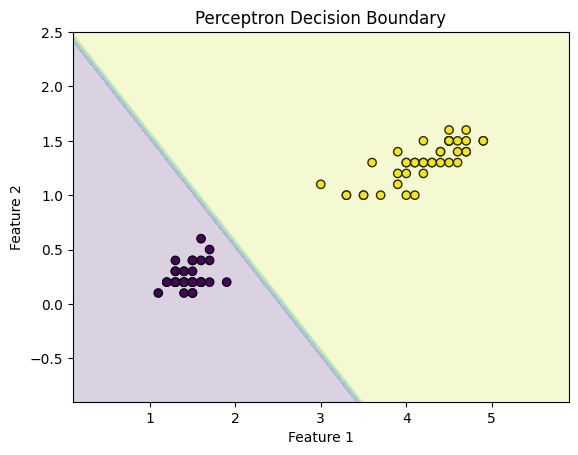

In [11]:
plt.scatter(train_x[:,0], train_x[:,1], c=train_y, 
            cmap='viridis', marker='o', edgecolor='k')

# create mesh grid
x_min, x_max = train_x[:,0].min() - 1, train_x[:,0].max() + 1
y_min, y_max = train_x[:,1].min() - 1, train_x[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# predict class for each point in mesh grid
z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

# plot decision boundary
plt.contourf(xx, yy, z, alpha=0.2, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.show()
